<a href="https://colab.research.google.com/github/muxicolin/SC3021-Lab-Project/blob/main/%E2%80%9CSC3021_Project_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Team 5, SC3021 Project***


In [ ]:
# Import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
# Load the .csv file stored in Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ***"What makes a song succeed on both Youtube and Spotify?"***

## --Analysis based on popular songs of popular artists

## **1. Hypothesis / Analysis Goal (Ask)**

**Project Background**

Music success is often measured by streaming counts on Spotify, or video views on YouTube, two dominating platforms of the music industry. However, due to their different recommendation mechanisms and user behaviors, a song that proves to be a big hit on one platform is not guaranteed to thrive on another.

In this project, we will explore popular songs that have made a breakthrough on both YouTube and Spotify, and analyze which audio characteristics contributed most to this cross-platform success, hoping to guide future artists and composers to rise in this music-craving yet media-driven world.

## **2. Data Source Identification & Exploration(Prepare)**

**Requirement Analysis**

To tackle the question, our group deems that the following aspects of a song or its MV on Spotify or YouTube need to be collected:

- **Basic Information**: Track, Artist, Release date, etc.
- **Audio Features**: Danceability, Energy, Key, Rythm, etc.(Based on information provided by Spotify API)
- **Popularity Features**: Streams on Spotify, Views on YouTube.

**List of Considered Sources**

By a throughout search on various database platforms such as Kaggle, we have collected the following datasets, among which DS1-3 will be applied, whereas DS4 has been excluded:  
[DS1: Spotify and Youtube*](https://www.kaggle.com/datasets/salvatorerastelli/spotify-and-youtube)

[DS2: 30000 Spotify Songs*](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs)

[DS3: YouTube Top 100 Songs 2025 Dataset*](https://www.kaggle.com/datasets/vedikagupta0/youtube-top-100-songs-2025-dataset)


[DS4: Spotify Most Streamed Songs](http://kaggle.com/datasets/abdulszz/spotify-most-streamed-songs)



### **DS1: Spotify and YouTube**

**Description**

This dataset, released recently in 2023, consists of 28 columns (26 variables), and specifically records basic information and critical audio characteristics for the top 10 songs of various Spotify artists and their corresponding YouTube videos in a ".csv" file format.

In [ ]:
# Read the DS1 .csv file
ds1 = pd.read_csv('/content/drive/MyDrive/SC3021 datasets/Spotify_Youtube.csv')

display(ds1)

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20713,20713,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,JUST DANCE HARDSTYLE,JUST DANCE HARDSTYLE,single,spotify:track:0RtcKQGyI4hr8FgFH1TuYG,0.582,0.926,5.0,...,https://www.youtube.com/watch?v=5SHmKFKlNqI,JUST DANCE HARDSTYLE,SICK LEGEND - Topic,71678.0,1113.0,0.0,Provided to YouTube by Routenote\n\nJUST DANCE...,True,True,9.227144e+06
20714,20714,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,SET FIRE TO THE RAIN HARDSTYLE,SET FIRE TO THE RAIN HARDSTYLE,single,spotify:track:3rHvPA8lUnPBkaLyPOc0VV,0.531,0.936,4.0,...,https://www.youtube.com/watch?v=ocTH6KxllDQ,SET FIRE TO THE RAIN HARDSTYLE,SICK LEGEND - Topic,164741.0,2019.0,0.0,Provided to YouTube by Routenote\n\nSET FIRE T...,True,True,1.089818e+07
20715,20715,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,OUTSIDE HARDSTYLE SPED UP,OUTSIDE HARDSTYLE SPED UP,single,spotify:track:4jk00YxPtPbhvHJE9N4ddv,0.443,0.830,4.0,...,https://www.youtube.com/watch?v=5wFhE-HY0hg,OUTSIDE HARDSTYLE SPED UP,SICK LEGEND - Topic,35646.0,329.0,0.0,Provided to YouTube by Routenote\n\nOUTSIDE HA...,True,True,6.226110e+06
20716,20716,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,ONLY GIRL HARDSTYLE,ONLY GIRL HARDSTYLE,single,spotify:track:5EyErbpsugWliX006eTDex,0.417,0.767,9.0,...,https://www.youtube.com/watch?v=VMFLbFRNCn0,ONLY GIRL HARDSTYLE,SICK LEGEND - Topic,6533.0,88.0,0.0,Provided to YouTube by Routenote\n\nONLY GIRL ...,True,True,6.873961e+06


**Explore the Artists Involved**

In [ ]:
### Below is the original AI output from Gemini

# Prompt: count the number of unique artists in ds1 and give a list of them
unique_artists = ds1['Artist'].unique()
print(f'List of unique artists:\n{unique_artists}')
print(f'\nThe number of unique artists is: {len(unique_artists)}')


List of unique artists:
['Gorillaz' 'Red Hot Chili Peppers' '50 Cent' ... 'LE SSERAFIM' 'ThxSoMch'
 'SICK LEGEND']

The number of unique artists is: 2079


According to data extraction from DS1, we observe that it covers a wide range of artists, providing ample data for analysis.

**Exploring the Streams and Views of MVs of Each Singer**

,Artist,Total Streams
0,$NOT,1.127638e+09
1,$uicideboy$,2.126748e+09
2,(G)I-DLE,1.304212e+09
3,*NSYNC,1.427834e+09
4,070 Shake,4.647486e+08


,Artist,Total YouTube Views
0,$NOT,1.107849e+08
1,$uicideboy$,3.341351e+08
2,(G)I-DLE,1.754954e+09
3,*NSYNC,1.027833e+09
4,070 Shake,9.609936e+07


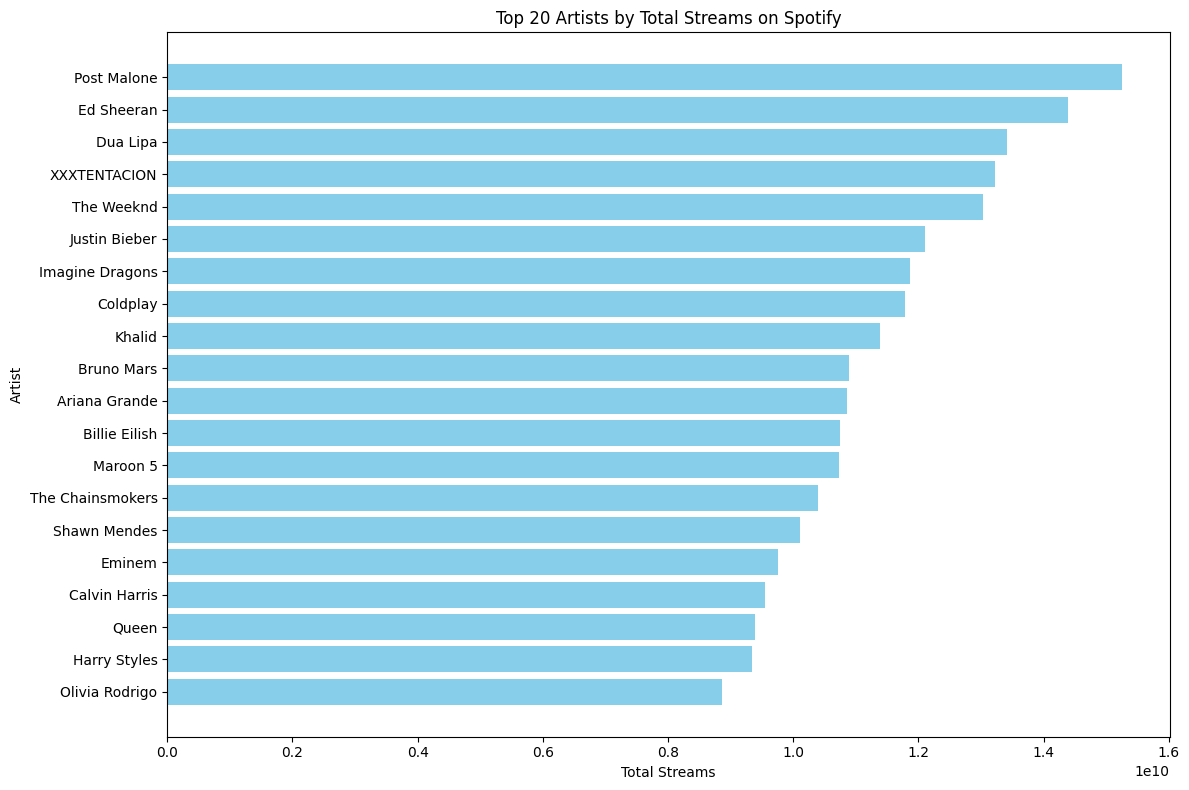

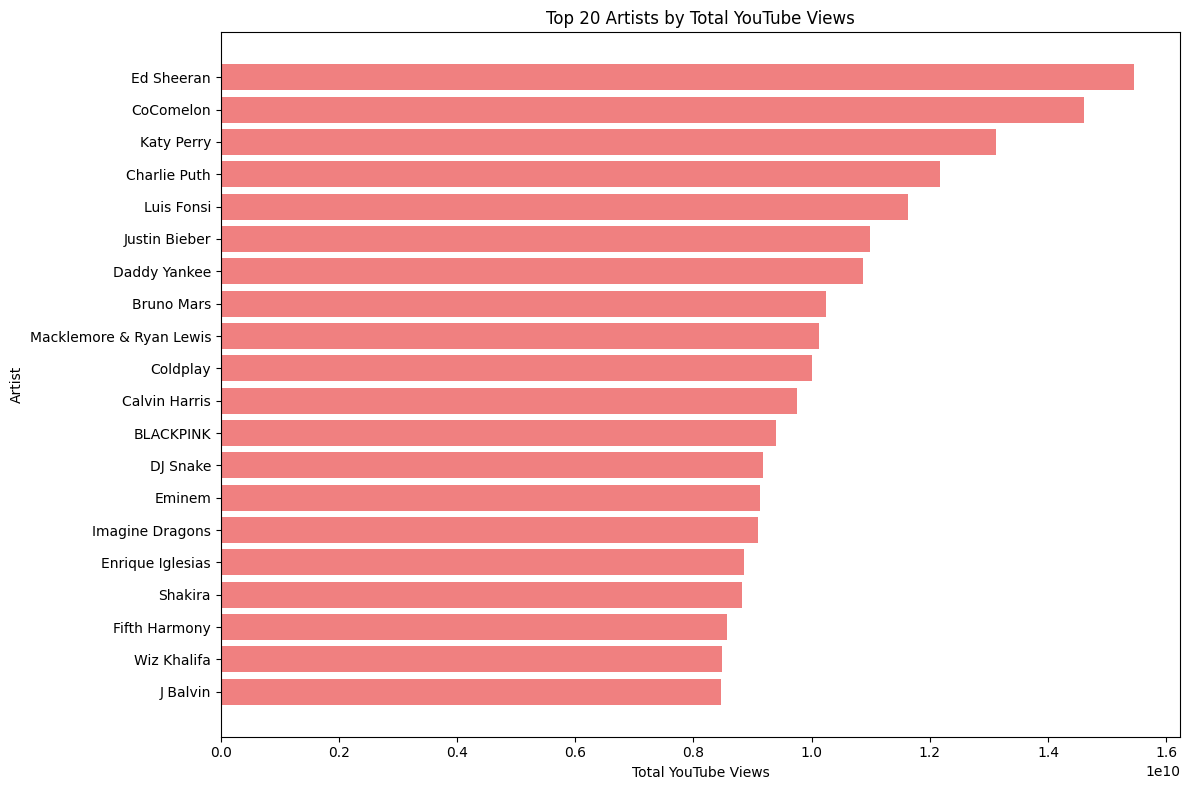

In [ ]:
### Below is the original AI output from Gemini in Google Colab

# Prompt: create a new data frame counting the total number of streams of each unique singer's songs from ds1
artist_streams = ds1.groupby('Artist')['Stream'].sum().reset_index()
artist_streams = artist_streams.rename(columns={'Stream': 'Total Streams'})
display(artist_streams.head())

# Prompt: create a new data frame counting the total number of streams of each unique singer's YouTube Mvs from ds1
artist_youtube_views = ds1.groupby('Artist')['Views'].sum().reset_index()
artist_youtube_views = artist_youtube_views.rename(columns={'Views': 'Total YouTube Views'})
display(artist_youtube_views.head())

# Prompt: plot the data frames into bar charts
# Sort the artists by total streams in descending order and take the top 20
top_artists_streams = artist_streams.sort_values(by='Total Streams', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_artists_streams['Artist'], top_artists_streams['Total Streams'], color='skyblue')
plt.xlabel('Total Streams')
plt.ylabel('Artist')
plt.title('Top 20 Artists by Total Streams on Spotify')
plt.gca().invert_yaxis() # Invert y-axis to have the highest stream artist at the top
plt.tight_layout()
plt.show()

# Sort the artists by total YouTube Views in descending order and take the top 20
top_artists_youtube = artist_youtube_views.sort_values(by='Total YouTube Views', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_artists_youtube['Artist'], top_artists_youtube['Total YouTube Views'], color='lightcoral')
plt.xlabel('Total YouTube Views')
plt.ylabel('Artist')
plt.title('Top 20 Artists by Total YouTube Views')
plt.gca().invert_yaxis() # Invert y-axis to have the highest view artist at the top
plt.tight_layout()
plt.show()


The charts generated above demonstrate singnificant differences in the total number of streams of each Spotify artist's top 10 songs. An explanation for such a phenomenon could be the difference in the total number of fans of each artist. Therefore, to avoid potential bias from differing fanbase sizes, we will only be comparing songs within each individual artist.

 **Data Quality Considerations**

Our group considers this dataset to be suitable for the following factors:

- **Comprehensiveness**: This dataset covers a wide range of singer/artists of different genres of music

- **Usability**: The attributes of each song are clearly stated with numerical values to be analyzed

- **Reputation**: This dataset found on Kaggle recieved high votes and many other users find it very useful

**Data Conclusion**

From our perspecitve, this dataset enables us to explore how musical attributes influence listener engagement on Spotify and YouTube, as well as cross-platform popularity patterns. With proper cleaning and normalization, it can support predictive modeling of song success, contributing to our topic.

### **DS2: 30000 Spotify Songs**

**Description**

 The dataset contains information on approximately 30,000 most-played songs collected from Spotify, comprising track metadata, audio features, and popularity indicators. It integrates musical characteristics with platform-level engagement metrics, enabling analysis of how song attributes relate to popularity and genre classification.



In [ ]:
# Read the ds2 .csv file
ds2 = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv')
display(ds2)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


**Exploring Genres**

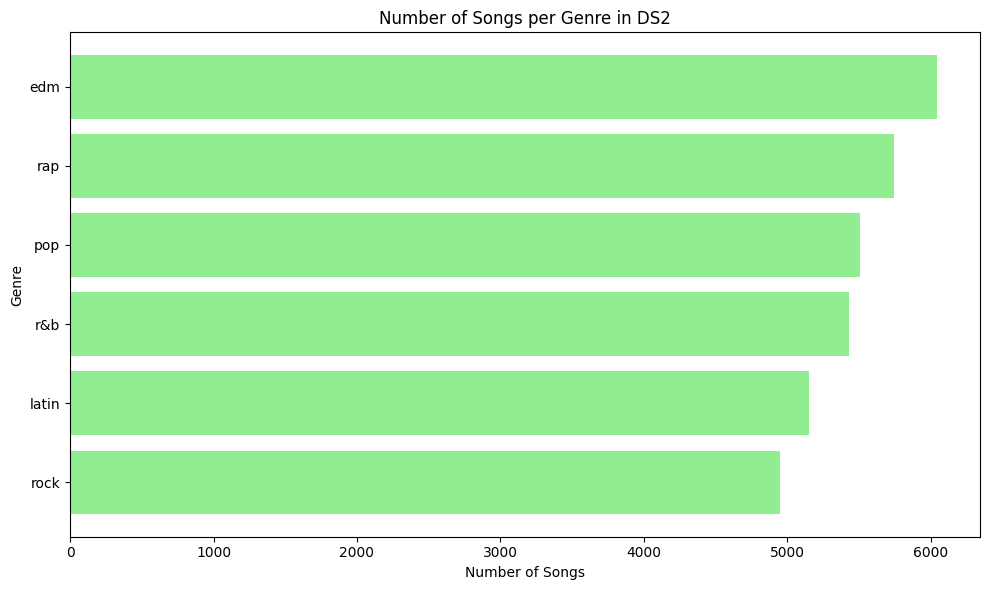

In [ ]:
### Below are the original output of Gemini in Google Colab

# Prompt: Count the number of songs in each genre in ds2 and plot a bar chart
# Count the number of songs in each genre
genre_counts = ds2['playlist_genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

# Plot a bar chart
plt.figure(figsize=(10, 6))
plt.barh(genre_counts['Genre'], genre_counts['Count'], color='lightgreen')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.title('Number of Songs per Genre in DS2')
plt.gca().invert_yaxis() # Invert y-axis to have the highest count at the top
plt.tight_layout()
plt.show()


According to data exploration, we observe that there is a wide range of genres covered in the dataset with "edm" in the lead, which has approximately 6000 songs. This introduces potential bias, since "edm" may dominate popular songs solely due to its large sample size, misleading us to overlook other audio features presented in genres with smaller sample sizes.

**Exploring Time Range**

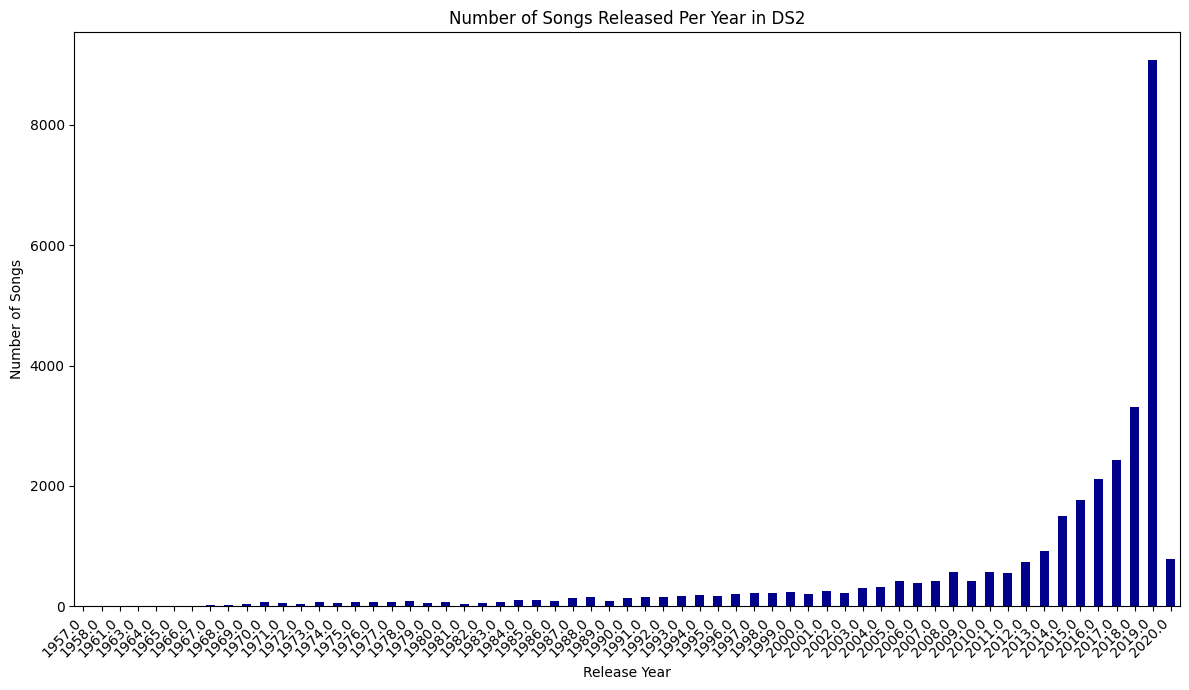

In [ ]:
### Below is the original output from Gemini in Google Colab

# Prompt: Count the number of songs in released in each year in ds2 and plot a bar chart

# Convert 'track_album_release_date' to datetime objects and extract the year
ds2['release_year'] = pd.to_datetime(ds2['track_album_release_date'], errors='coerce').dt.year

# Count the number of songs per year
year_counts = ds2['release_year'].value_counts().sort_index()

# Plot a bar chart
plt.figure(figsize=(12, 7))
year_counts.plot(kind='bar', color='darkblue')
plt.xlabel('Release Year')
plt.ylabel('Number of Songs')
plt.title('Number of Songs Released Per Year in DS2')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Exploring the release date proves to be crucial as people's music tastes change overtime. The bar chart illustrates that a multitude of songs were released from 2010 to 2020, peaking in 2019. Although this data recounts to a few years ago, it is still relatively accountable.

**Data Quality Considerations**

- **Large Sample Size**: With almost 30k songs included, it ensures ample data for this study.

- **Genre and Subgenre Labels**: Besides audio characteristics given by Spotify, this dataset also takes music genre into account, providing us with another factor that enriches the data, which could lead to a more comprehensive analysis.



**Data Conclusion**

 This dataset provides a comprehensive basis for exploring patterns in contemporary music on Spotify, particularly the relationship between audio features, genre classification, and song popularity. With proper preprocessing and normalization, it is well suited for the predictive modeling of popularity on Spotify, enable later comparison with the popularity on YouTube to find key characteristics for a cross-platform hit.

### **DS3: YouTube Top 100 Songs 2025 Dataset**

**Description**

This dataset captures the YouTube Top 100 Songs in 2025. Featuring comprehensive metadata for the year’s most popular tracks, including view counts, tags, categories etc.

In [ ]:
# Read the .csv file
ds3 = pd.read_csv('/content/drive/MyDrive/SC3021 datasets/youtube-top-100-songs-2025.csv')

display(ds3)

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
0,ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT.\nDownload/stream: ht...,2009014557,Music,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,2:53,False,https://i.ytimg.com/vi_webp/ekr2nIex040/maxres...,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...","Lady Gaga, Bruno Mars - Die With A Smile (Offi...",MAYHEM OUT NOW\nhttp://ladygaga.com \n \nListe...,1324833300,Music,Lady Gaga;Bruno Mars;Interscope;Pop,252,4:12,False,https://i.ytimg.com/vi/kPa7bsKwL-c/maxresdefau...,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,Reneé Rapp - Leave Me Alone (Official Music Vi...,"Listen to “BITE ME”, the new album from Reneé ...",2536628,Music,Reneé Rapp;Interscope Records;Pop,160,2:40,False,https://i.ytimg.com/vi/tiPWzFLiz4A/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000
3,Billie Eilish - BIRDS OF A FEATHER (Official M...,Billie Eilish - BIRDS OF A FEATHER (Official M...,Listen to HIT ME HARD AND SOFT: https://billie...,558329099,Music,Billie Eilish;Darkroom/Interscope Records;Alte...,231,3:51,False,https://i.ytimg.com/vi/V9PVRfjEBTI/maxresdefau...,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXo...,56800000
4,Reneé Rapp - Mad (Official Music Video),Reneé Rapp - Mad (Official Music Video),"Listen to “BITE ME”, the new album from Reneé ...",2113548,Music,Reneé Rapp;Interscope Records;Pop,180,3:00,False,https://i.ytimg.com/vi/xkWQM3flsiY/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Ariana Grande - twilight zone (Official Lyric ...,Ariana Grande - twilight zone (Official Lyric ...,The official “twilight zone” official lyric vi...,18245315,Music,Ariana Grande;Republic Records;Pop,202,3:22,False,https://i.ytimg.com/vi/x1XIJM6spaE/maxresdefau...,Ariana Grande,https://www.youtube.com/channel/UC0VOyT2OCBKdQ...,56400000
96,"Gracie Abrams - I Love You, I’m Sorry (Officia...","Gracie Abrams - I Love You, I’m Sorry (Officia...","Listen to the new album, The Secret of Us, out...",31456772,Music,"Gracie Abrams;Gracie Abrams, under exclusive l...",234,3:54,False,https://i.ytimg.com/vi/uxjhN_Donfw/maxresdefau...,Gracie Abrams,https://www.youtube.com/channel/UCVFRVXH1hRoWk...,1770000
97,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino and FCG Heem drop Miami. From...,66051,Music,NaN,197,3:17,False,https://i.ytimg.com/vi_webp/I-gmbHgeN1I/maxres...,HoodTrophy Bino,https://www.youtube.com/channel/UCsaZi3QZrZ5-s...,20300
98,Sean Paul x INNA - Let It Talk To Me,Sean Paul x INNA - Let It Talk To Me,Song Title: Sean Paul x INNA - Let It Talk To ...,16952860,Music,Sean Paul,155,2:35,False,https://i.ytimg.com/vi_webp/nkRyAVQdqAA/maxres...,Sean Paul,https://www.youtube.com/channel/UCkdc7gHpavxpg...,5200000


**Exploring View Distribution**

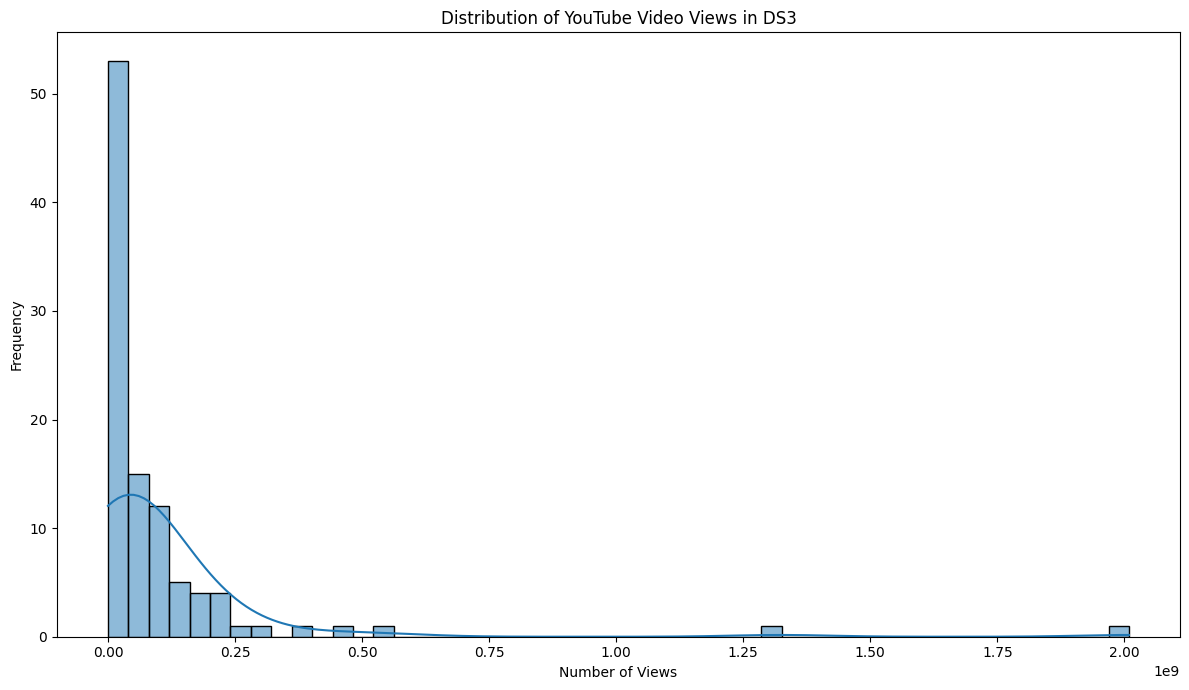

In [ ]:
### Below is the original outout from Gemini in Google Colab

# Prompt: Plot a chart on the distribution of number of views of Youtube videos in ds3

plt.figure(figsize=(12,7))

sns.histplot(ds3['view_count'], bins=50, kde=True)

plt.xlabel('Number of Views')
plt.ylabel('Frequency')
plt.title('Distribution of YouTube Video Views in DS3')

plt.tight_layout()
plt.show()

From the distribution we can see that most of the songs have their view counts around 100~200 million, indicating the dataset is indeed featuring top songs instead of random music video uploads.

**Data Quality Considerations**

- **Managable Size**: Compared to DS1 and DS2 with huge numbers of rows, this data set only contains the most popular songs on Youtube in 2025 making the analysis process simplier.

- **Temporality**: This dataset was collected in 2025, enabling a more accurate analysis for songs recently.

- **Platform Specific**: The dataset solely focuses on YouTube MVs. Despite "number of views" being the only numerical attribute provided, by data enriching and linking DS2 and DS3 dynamically, we are able to complete the neccessary audio characteristics for analysis.


**Data Conclusion**

Overall, the YouTube Top Songs 2020-2023 dataset offers a concise yet powerful view of contemporary music popularity on YouTube. Its strong focus on high-impact songs and clear engagement indicators makes it well suited for our topic of trend analysis of hit songs and music.

### **DS4: Spotify Most Streamed Songs (Not Used)**

**Description**

The dataset focuses on the most streamed songs on Spotify, emphasizing song popularity by showing the songs streams and occurence in Spotify and Apple Music playlists.

In [ ]:
# Read the .csv file
ds4 = pd.read_csv('/content/drive/MyDrive/SC3021 datasets/Spotify Most Streamed Songs.csv')

display(ds4)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,Not Found
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,https://i.scdn.co/image/ab67616d0000b2730656d5...
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,https://i.scdn.co/image/ab67616d0000b273e85259...
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,https://i.scdn.co/image/ab67616d0000b273e787cf...
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,https://i.scdn.co/image/ab67616d0000b273ab5c9c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,A,Major,60,24,39,57,0,8,3,https://i.scdn.co/image/ab67616d0000b2730f5397...
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,F#,Major,42,7,24,83,1,12,6,https://i.scdn.co/image/ab67616d0000b273e0b60c...
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,C#,Major,80,81,67,4,0,8,6,Not Found
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,C#,Major,82,67,77,8,0,12,5,Not Found


**Exploring the Number of Artists Involved**

In [ ]:
# Find the number of unque involved
unique_artists2 = ds4['artist(s)_name'].unique()
print(f'List of unique artists:\n{unique_artists}')
print(f'\nThe number of unique artists is: {len(unique_artists)}')

List of unique artists:
['Gorillaz' 'Red Hot Chili Peppers' '50 Cent' ... 'LE SSERAFIM' 'ThxSoMch'
 'SICK LEGEND']

The number of unique artists is: 2079


Despite including a wide range of artists, the number of songs of each artist is relatively low compared to that of DS1, making comparison within each individual artist difficult due to small sample size.

**Data Quality Considerations**

- **Incomplete Values**: Large quantity of missing values increases difficulty during the analysis stage.

- **Relative size of the data**: This dataset has the same data types and attributes as DS1, only with a much smaller sample size.


**Data Conclusion**

This dataset is not selected because it only includes few top-streamed songs, causing selection bias. In addition, features are limited to play-list-specific metrics and streams only, indicating this dataset to be inappropriate for this project.

## **3. Data Preparation (Process)**

**Brief Overview**

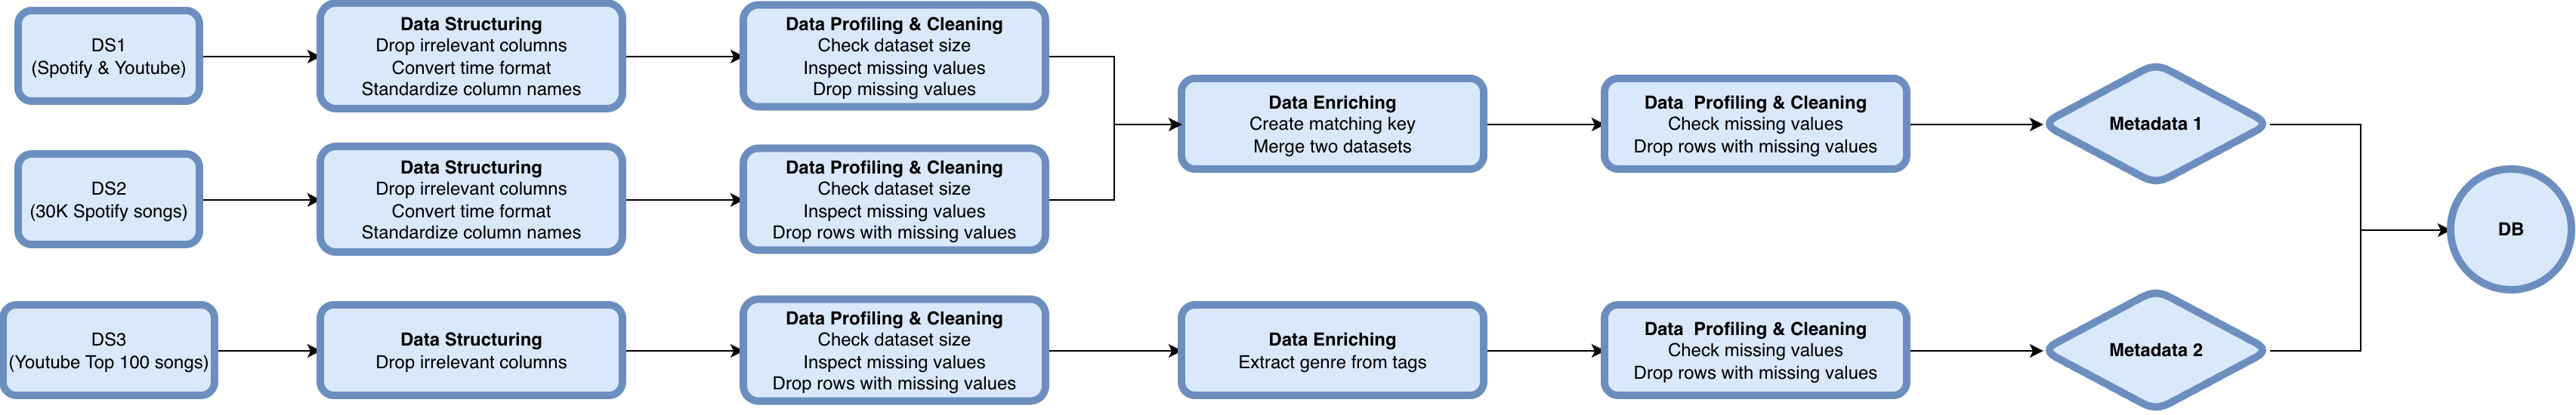

### **A. Data Structuring**

**1. Remove Irrelevant Columns**

We'll remove some columns in DS1, DS2 and DS3 as they include irrelevant information that do not help on the analysis.

In [ ]:
# Drop Irrelevant columns
spotifyAndYoutube = ds1.drop(columns = ["Url_spotify", "Album", "Album_type", "Uri", "Url_youtube", "Title", "Channel", "Description", "Licensed", "official_video"])
spotifySongs = ds2.drop(columns = ["track_id", "track_album_id","track_album_name", "track_album_release_date", "playlist_name", "playlist_id", "mode", "track_popularity"])
youtubeTopSongs2025 = ds3.drop(columns = ["fulltitle", "categories", "description", "duration_string", "live_status", "thumbnail"])


**2. Data Conversion**

We'll convert the duration of the song from millisecond to second in DS1 and DS2 to allow a more intuitive analysis.

In [ ]:
# A second equals 1000ms
def millisecToSec(ms):
  sec = ms / 1000
  return sec

# Convert ms in each dataset to s
spotifyAndYoutube["Duration_ms"] = spotifyAndYoutube["Duration_ms"].apply(millisecToSec)
spotifySongs["duration_ms"] = spotifySongs["duration_ms"].apply(millisecToSec)

# Rename the column
spotifyAndYoutube = spotifyAndYoutube.rename(columns = {"Duration_ms": "Duration"})
spotifySongs = spotifySongs.rename(columns = {"duration_ms": "Duration"})

**3. Standardize Column Names**

DS1 and DS2, being different datasets, have different column names. Therefore, for the merge of data later, we have to unify column names in both datasets here.


In [ ]:
# Make column names to lowercase letters
spotifyAndYoutube.columns = spotifyAndYoutube.columns.str.lower()
spotifySongs.columns = spotifySongs.columns.str.lower()
youtubeTopSongs2025.columns = youtubeTopSongs2025.columns.str.lower()

# Rename columns in DS2
spotifySongs = spotifySongs.rename(columns = {"track_name": "track", "track_artist": "artist"})


### **B. Data Profiling**

**1. Check Dataset Sizes**

We start by examining the shape and columns of each dataset to understand how many songs are available

In [ ]:
print(spotifyAndYoutube.shape)
print(spotifySongs.shape)
print(youtubeTopSongs2025.shape)

(20718, 18)
(32833, 16)
(100, 7)


**2. Inspect Missing Values**

We quantify missing values in each dataset to identify incomplete data. Understanding the proportion of nulls helps us decide how to handle them.

In [ ]:
nullPercentDs1 = spotifyAndYoutube.isnull().sum() / len(spotifyAndYoutube) * 100
nullPercentDs2 = spotifySongs.isnull().sum() / len(spotifySongs) * 100
nullPercentDs3 = youtubeTopSongs2025.isnull().sum() / len(youtubeTopSongs2025) * 100

print("DS1 null %:\n", nullPercentDs1)
print("DS2 null %:\n", nullPercentDs2)
print("DS3 null %:\n", nullPercentDs3)

DS1 null %:
 unnamed: 0          0.000000
artist              0.000000
track               0.000000
danceability        0.009653
energy              0.009653
key                 0.009653
loudness            0.009653
speechiness         0.009653
acousticness        0.009653
instrumentalness    0.009653
liveness            0.009653
valence             0.009653
tempo               0.009653
duration            0.009653
views               2.268559
likes               2.611256
comments            2.746404
stream              2.780191
dtype: float64
DS2 null %:
 track                0.015229
artist               0.015229
playlist_genre       0.000000
playlist_subgenre    0.000000
danceability         0.000000
energy               0.000000
key                  0.000000
loudness             0.000000
speechiness          0.000000
acousticness         0.000000
instrumentalness     0.000000
liveness             0.000000
valence              0.000000
tempo                0.000000
duration         

- In DS1 and DS2, we can see that there's only few missing values with low percentage, so we'll simply perform data cleaning by dropping the null values

- In DS3, due to the relatively small dataset size, simply drop null rows is not the best option. So we decided to add rows with missing tags manually by searching them in youtube.

### **C. Data Cleaning**

**1. Clean The Key Fields**

By removing case, spacing issues and possible duplicates, this step helps avoid potential problem which may happen later when we create a new key for identifying songs using names

Also, cleaning the track name is important as many songs contain unneccessary information like:
- (feat....)
- remastered
- live
- remix
etc.

By dropping these extra information we can more clearly identify a unique song.

In [ ]:
# Unify case and remove potential spacings
for df in [spotifyAndYoutube, spotifySongs]:
  df["track"] = df["track"].astype(str).str.lower().str.strip()
  df["artist"] = df["artist"].astype(str).str.lower().str.strip()
  df = df.drop_duplicates()


# Cleaning unecessary information
def cleanTitle(title):
  title = re.sub(r"\(.*\)", "", title) # Remove (feat...) etc.
  title = re.sub(r"-.*", "", title) # Remove -Remastered, -live, -remix etc.
  return title.strip() # Retrun the cleaned title

 # Not youtubeTopSongs this time as in this dataset artists & song names are connected by "-"
for df in [spotifyAndYoutube, spotifySongs]:
  df["track"] = df["track"].apply(cleanTitle)

**2, Dealing Null Values**

In this step we'll do the following 2 things:

- Drop rows with null values in DS1 and DS2
- Extract the rows in DS3 with empty tags and see if we can enrich them manually.

In [ ]:
# Drop empty rows in DS1 & DS2
spotifyAndYoutube = spotifyAndYoutube.dropna()
spotifySongs = spotifySongs.dropna()


# Extract empty rows from DS3
emptyTags = youtubeTopSongs2025[youtubeTopSongs2025['tags'].isnull()]
display(emptyTags)

,title,view_count,tags,duration,channel,channel_url,channel_follower_count
10,Zillionaire Doe - How It's Going (Official Video),1198540,NaN,152,Zillionaire Doe,https://www.youtube.com/channel/UCbVdo2e1hDYR9...,142000
11,Alex Warren - Ordinary (Official Video),147871443,NaN,187,Alex Warren,https://www.youtube.com/channel/UCX2Pm1JoWF3ch...,4050000
12,Kendrick Lamar - luther (Official Audio),142084039,NaN,178,Kendrick Lamar,https://www.youtube.com/channel/UC3lBXcrKFnFAF...,19700000
22,Tommy Richman - MILLION DOLLAR BABY (Official ...,45822601,NaN,156,Tommy Richman,https://www.youtube.com/channel/UC7eumlwt8zpmN...,655000
25,"Adam Port, Stryv - Move feat. Malachiii (Exten...",87005996,NaN,353,keinemusik,https://www.youtube.com/channel/UCYzx8QoAiRb69...,255000
26,Tutipsy & Niickii - Afro Disco (Visualizer),17322,NaN,154,NIICKII,https://www.youtube.com/channel/UChcyluLsfj0ge...,47
31,NIGHT SKIES (Official Music Video),6605,NaN,137,Chxnny,https://www.youtube.com/channel/UCcA274LONuELr...,3630
32,SEVDALIZA - ALIBI FT. PABLLO VITTAR & YSEULT (...,236500879,NaN,193,Sevdaliza,https://www.youtube.com/channel/UCONnf7g7QfOqz...,1230000
35,squabble up,70965585,NaN,166,Kendrick Lamar,https://www.youtube.com/channel/UC3lBXcrKFnFAF...,19700000
44,David Guetta & Sia - Beautiful People (Officia...,41075369,NaN,204,David Guetta,https://www.youtube.com/channel/UC1l7wYrva1qCH...,27600000


However, after searching the songs with missing tags in YouTube, we find that instead of not collecting the tags in the dataset, these videos are not tagged when being uploaded, therefore we have no choice but to drop them.

In [ ]:
youtubeTopSongs2025 = youtubeTopSongs2025.dropna()

### **D. Data Enriching**

**1. Create a Match Key**

Since the dataset contains many songs of the same artists and there might be songs from different artists with the same name, here our match key will be "artist + track name", as they usually can uniquely identify a song. Since song names in DS3 is already in the format of match key, there's no need to apply the method to DS3.

In [ ]:
# Merge Key: track + artist
for df in [spotifyAndYoutube, spotifySongs]:
  spotifyAndYoutube['match_key'] = spotifyAndYoutube['artist'] + ' - ' + spotifyAndYoutube['track']
  spotifySongs['match_key'] = spotifySongs['artist'] + ' - ' + spotifySongs['track']

In [ ]:
display(spotifySongs)

,track,artist,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,release_year,match_key
0,i don't care,ed sheeran,pop,dance pop,0.748,0.916,6,-2.634,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194.754,2019.0,ed sheeran - i don't care
1,memories,maroon 5,pop,dance pop,0.726,0.815,11,-4.969,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162.600,2019.0,maroon 5 - memories
2,all the time,zara larsson,pop,dance pop,0.675,0.931,1,-3.432,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176.616,2019.0,zara larsson - all the time
3,call you mine,the chainsmokers,pop,dance pop,0.718,0.930,7,-3.778,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169.093,2019.0,the chainsmokers - call you mine
4,someone you loved,lewis capaldi,pop,dance pop,0.650,0.833,1,-4.672,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189.052,2019.0,lewis capaldi - someone you loved
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,city of lights,lush & simon,edm,progressive electro house,0.428,0.922,2,-1.814,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204.375,2014.0,lush & simon - city of lights
32829,closer,tegan and sara,edm,progressive electro house,0.522,0.786,0,-4.462,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353.120,2013.0,tegan and sara - closer
32830,sweet surrender,starkillers,edm,progressive electro house,0.529,0.821,6,-4.899,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210.112,2014.0,starkillers - sweet surrender
32831,only for you,mat zo,edm,progressive electro house,0.626,0.888,2,-3.361,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367.432,2014.0,mat zo - only for you


**2. Add new attributes**

For the analysis of song genres, there're 2 things we'll do:
- Based on the match_key, merge the row "playlist_genre" in DS2 with songs in DS1 to add the genre attribute to DS1 songs

- Extract genre of songs in DS3 in the row "tags" to allow analysis on music genres

In [ ]:
# Merge the 2 datasets on match_key
spotifyAndYoutubeMerged = spotifyAndYoutube.merge(spotifySongs[['match_key', 'playlist_genre']], on='match_key', how='left')
display(spotifyAndYoutubeMerged)

# Extract the genre from tags in DS3

# Common music tags that could appear
genres = [
    'pop', 'dance pop', 'teen pop', 'synth-pop', 'k-pop', 'j-pop',
    'rock', 'classic rock', 'indie rock', 'alternative rock', 'punk rock', 'hard rock', 'metal', 'grunge', 'emo',
    'hip hop', 'rap', 'trap', 'lo-fi hip hop', 'conscious rap', 'gangsta rap',
    'edm', 'house', 'techno', 'trance', 'dubstep', 'drum and bass', 'chillout', 'future bass', 'synthwave',
    'r&b', 'neo soul', 'soul', 'funk', 'motown',
    'jazz', 'smooth jazz', 'bebop', 'blues', 'blues rock', 'swing',
    'country', 'country pop', 'bluegrass', 'folk', 'indie folk', 'americana',
    'classical', 'baroque', 'romantic', 'contemporary classical', 'soundtrack', 'instrumental',
    'reggae', 'dancehall', 'afrobeat', 'latin', 'salsa', 'tango', 'flamenco',
    'punk', 'metalcore', 'emo', 'lo-fi', 'experimental', 'ambient', 'chillwave', 'vaporwave'
]

def extractGenre(tags):
  tags = str(tags)
  tags = tags.strip().lower()
  tagList = tags.split(";")

  genreList = [t for t in tagList if t in genres]
  # Keep the tags that match the genre
  tagList = [t for t in tagList if t in genres]
  return ",".join(tagList)

youtubeTopSongs2025['genres'] = youtubeTopSongs2025['tags'].apply(extractGenre)

display(youtubeTopSongs2025)


,unnamed: 0,artist,track,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,views,likes,comments,stream,match_key,playlist_genre
0,0,gorillaz,feel good inc.,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.6130,0.7720,138.559,222.640,693555221.0,6220896.0,169907.0,1.040235e+09,gorillaz - feel good inc.,rock
1,0,gorillaz,feel good inc.,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.6130,0.7720,138.559,222.640,693555221.0,6220896.0,169907.0,1.040235e+09,gorillaz - feel good inc.,rock
2,1,gorillaz,rhinestone eyes,0.676,0.703,8.0,-5.815,0.0302,0.086900,0.000687,0.0463,0.8520,92.761,200.173,72011645.0,1079128.0,31003.0,3.100837e+08,gorillaz - rhinestone eyes,NaN
3,2,gorillaz,new gold,0.695,0.923,1.0,-3.930,0.0522,0.042500,0.046900,0.1160,0.5510,108.014,215.150,8435055.0,282142.0,7399.0,6.306347e+07,gorillaz - new gold,NaN
4,3,gorillaz,on melancholy hill,0.689,0.739,2.0,-5.810,0.0260,0.000015,0.509000,0.0640,0.5780,120.423,233.867,211754952.0,1788577.0,55229.0,4.346636e+08,gorillaz - on melancholy hill,pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22839,20713,sick legend,just dance hardstyle,0.582,0.926,5.0,-6.344,0.0328,0.448000,0.000000,0.0839,0.6580,90.002,94.667,71678.0,1113.0,0.0,9.227144e+06,sick legend - just dance hardstyle,NaN
22840,20714,sick legend,set fire to the rain hardstyle,0.531,0.936,4.0,-1.786,0.1370,0.028000,0.000000,0.0923,0.6570,174.869,150.857,164741.0,2019.0,0.0,1.089818e+07,sick legend - set fire to the rain hardstyle,NaN
22841,20715,sick legend,outside hardstyle sped up,0.443,0.830,4.0,-4.679,0.0647,0.024300,0.000000,0.1540,0.4190,168.388,136.842,35646.0,329.0,0.0,6.226110e+06,sick legend - outside hardstyle sped up,NaN
22842,20716,sick legend,only girl hardstyle,0.417,0.767,9.0,-4.004,0.4190,0.356000,0.018400,0.1080,0.5390,155.378,108.387,6533.0,88.0,0.0,6.873961e+06,sick legend - only girl hardstyle,NaN


,title,view_count,tags,duration,channel,channel_url,channel_follower_count,genres
0,ROSÉ & Bruno Mars - APT. (Official Music Video),2009014557,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000,k-pop
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...",1324833300,Lady Gaga;Bruno Mars;Interscope;Pop,252,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000,pop
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,2536628,Reneé Rapp;Interscope Records;Pop,160,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000,pop
3,Billie Eilish - BIRDS OF A FEATHER (Official M...,558329099,Billie Eilish;Darkroom/Interscope Records;Alte...,231,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXo...,56800000,
4,Reneé Rapp - Mad (Official Music Video),2113548,Reneé Rapp;Interscope Records;Pop,180,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000,pop
...,...,...,...,...,...,...,...,...
94,Justin Bieber - YUKON,21968615,justin;bieber;justinbieber;purpose;myworld;jou...,183,Justin Bieber,https://www.youtube.com/channel/UCIwFjwMjI0y7P...,76200000,"r&b,pop"
95,Ariana Grande - twilight zone (Official Lyric ...,18245315,Ariana Grande;Republic Records;Pop,202,Ariana Grande,https://www.youtube.com/channel/UC0VOyT2OCBKdQ...,56400000,pop
96,"Gracie Abrams - I Love You, I’m Sorry (Officia...",31456772,"Gracie Abrams;Gracie Abrams, under exclusive l...",234,Gracie Abrams,https://www.youtube.com/channel/UCVFRVXH1hRoWk...,1770000,pop
98,Sean Paul x INNA - Let It Talk To Me,16952860,Sean Paul,155,Sean Paul,https://www.youtube.com/channel/UCkdc7gHpavxpg...,5200000,


**3. Profiling and Drop Null rows**

In this step we find the number of rows containing null values and drop them

In [ ]:
# Count the number of nulls
spotifyAndYoutubeNullCount = spotifyAndYoutubeMerged.isnull().sum()
youtubeTopSongs2025NullCount = youtubeTopSongs2025.isnull().sum()

print("DS1 null count:\n", spotifyAndYoutubeNullCount)
print("DS3 null count:\n", youtubeTopSongs2025NullCount)

# Drop the number of nulls
spotifyAndYoutubeMerged = spotifyAndYoutubeMerged.dropna() # Final Dataset1
youtubeTopSongs2025 = youtubeTopSongs2025.dropna() # Final Datset2

print(spotifyAndYoutubeMerged.shape)
print(youtubeTopSongs2025.shape)

display(spotifyAndYoutubeMerged.head())
display(youtubeTopSongs2025.head())

DS1 null count:
 unnamed: 0              0
artist                  0
track                   0
danceability            0
energy                  0
key                     0
loudness                0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
duration                0
views                   0
likes                   0
comments                0
stream                  0
match_key               0
playlist_genre      16679
dtype: int64
DS3 null count:
 title                     0
view_count                0
tags                      0
duration                  0
channel                   0
channel_url               0
channel_follower_count    0
genres                    0
dtype: int64
(6165, 20)
(85, 8)


,unnamed: 0,artist,track,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,views,likes,comments,stream,match_key,playlist_genre
0,0,gorillaz,feel good inc.,0.818,0.705,6.0,-6.679,0.177,0.008360,0.00233,0.613,0.772,138.559,222.640,6.935552e+08,6220896.0,169907.0,1.040235e+09,gorillaz - feel good inc.,rock
1,0,gorillaz,feel good inc.,0.818,0.705,6.0,-6.679,0.177,0.008360,0.00233,0.613,0.772,138.559,222.640,6.935552e+08,6220896.0,169907.0,1.040235e+09,gorillaz - feel good inc.,rock
4,3,gorillaz,on melancholy hill,0.689,0.739,2.0,-5.810,0.026,0.000015,0.50900,0.064,0.578,120.423,233.867,2.117550e+08,1788577.0,55229.0,4.346636e+08,gorillaz - on melancholy hill,pop
10,9,gorillaz,dirty harry,0.625,0.877,10.0,-7.176,0.162,0.031500,0.08110,0.672,0.865,192.296,230.426,1.547611e+08,1386920.0,39240.0,1.910747e+08,gorillaz - dirty harry,rock
11,10,red hot chili peppers,californication,0.592,0.767,9.0,-2.788,0.027,0.002100,0.00165,0.127,0.328,96.483,329.733,1.018811e+09,4394471.0,121452.0,1.055738e+09,red hot chili peppers - californication,rock


,title,view_count,tags,duration,channel,channel_url,channel_follower_count,genres
0,ROSÉ & Bruno Mars - APT. (Official Music Video),2009014557,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000,k-pop
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...",1324833300,Lady Gaga;Bruno Mars;Interscope;Pop,252,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000,pop
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,2536628,Reneé Rapp;Interscope Records;Pop,160,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000,pop
3,Billie Eilish - BIRDS OF A FEATHER (Official M...,558329099,Billie Eilish;Darkroom/Interscope Records;Alte...,231,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXo...,56800000,
4,Reneé Rapp - Mad (Official Music Video),2113548,Reneé Rapp;Interscope Records;Pop,180,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000,pop
